<a href="https://colab.research.google.com/github/Piyush-47928/DEEP-LEARNING/blob/main/Crowd_Survillance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision facenet-pytorch scikit-learn scipy matplotlib seaborn tqdm umap-learn --quiet

import os, sys, zipfile, shutil, random, time, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageFilter
import math as _math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc as sk_auc,
    precision_score, recall_score, accuracy_score
)
from sklearn.neighbors import NearestNeighbors
import scipy.linalg
import umap
from google.colab import files

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32      = True

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"AMP      : {USE_AMP}")
print(f"UMAP     : {umap.__version__}")
print("All dependencies loaded ✓")

PyTorch  : 2.10.0+cu128
Device   : cuda
AMP      : True
UMAP     : 0.5.11
All dependencies loaded ✓


In [3]:
print("Upload your dataset ZIP:")
uploaded = files.upload()

EXTRACT_DIR = "/content/dataset_raw"
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR)

for zname in uploaded.keys():
    with zipfile.ZipFile(zname, "r") as z:
        z.extractall(EXTRACT_DIR)
    print(f"Extracted : {zname}")

def find_dataset_root(base):
    for root, dirs, _ in os.walk(base):
        valid = [
            d for d in sorted(dirs)
            if any(
                f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))
                for f in os.listdir(os.path.join(root, d))
            )
        ]
        if len(valid) >= 2:
            return root
    return base

DATASET_PATH = find_dataset_root(EXTRACT_DIR)
CLASSES      = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
N_CLASSES = len(CLASSES)

print(f"\nDataset root : {DATASET_PATH}")
print(f"Identities   : {N_CLASSES}\n")

total_imgs = 0
for cls in CLASSES:
    n = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, cls))
        if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))
    ])
    total_imgs += n
    tag = "  ⚠ low" if n < 5 else "  ✓"
    print(f"  {cls:<30}: {n:>4} images{tag}")

print(f"\nTotal images : {total_imgs}")
if N_CLASSES < 2:
    raise RuntimeError("Need at least 2 identity folders.")

Upload your dataset ZIP:


Saving Faces.zip to Faces.zip
Extracted : Faces.zip

Dataset root : /content/dataset_raw/Faces
Identities   : 31

  Akshay Kumar                  :   50 images  ✓
  Alexendera Daddario           :   92 images  ✓
  Alia Bhatt                    :   79 images  ✓
  Amitabh Bachan                :   74 images  ✓
  Andy Samberg                  :   92 images  ✓
  Anushka Sharma                :   68 images  ✓
  Billie Eillish                :   98 images  ✓
  Brad Pitt                     :  120 images  ✓
  Camila Cambello               :   87 images  ✓
  Charlize Theron               :   78 images  ✓
  Claire Holt                   :   96 images  ✓
  Courtney Cox                  :   80 images  ✓
  Dwayne Johnson                :   61 images  ✓
  Elizabeth Olsen               :   71 images  ✓
  Ellen Degeneres               :   75 images  ✓
  Henry Cavill                  :  106 images  ✓
  Hrithik Roshan                :  101 images  ✓
  Hugh Jackman                  :  112 images  ✓
  Je

In [16]:
class CFG:
    # Paths
    data_dir         = DATASET_PATH
    ckpt_dir         = "/content/checkpoints"
    results_dir      = "/content/results"
    cache_dir        = "/content/emb_cache"

    # Image
    img_size         = 112

    # CNN Backbone
    cnn_emb_dim      = 512

    # Supervised LLE  (512D → 128D)
    lle_output_dim   = 128
    lle_k            = 12
    lle_alpha        = 0.7          # same-class neighbor weight
    lle_beta         = 0.3          # diff-class neighbor weight
    lle_refit_every  = 15          # epochs between LLE refit

    # UMAP  (128D → 64D)
    umap_output_dim  = 64
    umap_neighbors   = 15
    umap_min_dist    = 0.1
    umap_metric      = "cosine"
    umap_supervised  = True
    umap_refit_every = 10

    # Siamese Head  (64D → 32D)
    sia_hidden       = 128
    sia_emb_dim      = 32

    # Training
    batch_size       = 128
    num_epochs       = 80
    lr               = 1e-3
    weight_decay     = 1e-4
    warmup_epochs    = 8
    min_lr           = 1e-5 # Added min_lr
    dropout          = 0.35

    # Loss
    triplet_margin   = 0.3
    ce_weight        = 0.4
    triplet_weight   = 0.6

    # Hard mining
    mining_start     = 8
    n_per_anchor     = 8

    # K-Fold
    n_folds          = 5

    # Data split
    val_split        = 0.20
    min_imgs_cls     = 2

    # Augmentation
    aug_rotation     = 15.0
    aug_brightness   = 0.4
    aug_contrast     = 0.4
    aug_noise_std    = 0.025
    aug_blur_prob    = 0.25
    aug_occ_prob     = 0.20
    aug_occ_ratio    = 0.20

    # Early stopping
    patience         = 18
    min_delta        = 5e-5

    # Speed
    eval_every       = 5
    max_eval_imgs    = 400
    n_thresholds     = 400
    num_workers      = 8 if torch.cuda.is_available() else 0
    prefetch_factor  = 6 if torch.cuda.is_available() else 2
    compile_model    = True
    cache_cnn_embs   = True

for d in [CFG.ckpt_dir, CFG.results_dir, CFG.cache_dir]:
    os.makedirs(d, exist_ok=True)

print("Configuration ready ✓")
print(f"Pipeline : MTCNN"
      f" → MobileNet({CFG.cnn_emb_dim}D)"
      f" → LLE({CFG.lle_output_dim}D)"
      f" → UMAP({CFG.umap_output_dim}D)"
      f" → Siamese({CFG.sia_emb_dim}D)")
print(f"Batch Size      : {CFG.batch_size}")
print(f"Workers         : {CFG.num_workers}")
print(f"LLE refit every : {CFG.lle_refit_every}")
print(f"CNN emb cache   : {CFG.cache_cnn_embs}")

Configuration ready ✓
Pipeline : MTCNN → MobileNet(512D) → LLE(128D) → UMAP(64D) → Siamese(32D)
Batch Size      : 128
Workers         : 8
LLE refit every : 15
CNN emb cache   : True


In [17]:
class FaceDetector:
    def __init__(self, img_size=112, device="cpu"):
        self.img_size = img_size
        self._ok      = False
        try:
            from facenet_pytorch import MTCNN
            self._mtcnn = MTCNN(
                image_size=img_size, margin=14,
                keep_all=False, post_process=False,
                device=device, select_largest=True,
                min_face_size=20,
            )
            self._ok = True
            print("MTCNN loaded ✓")
        except Exception as e:
            print(f"MTCNN unavailable ({e}) — resize fallback.")
        self._fallback = T.Resize((img_size, img_size))

    def __call__(self, img):
        if not self._ok:
            return self._fallback(img)
        try:
            face = self._mtcnn(img)
            if face is not None:
                arr = face.permute(1, 2, 0).byte().numpy()
                return Image.fromarray(arr)
        except Exception:
            pass
        return self._fallback(img)


class GaussianNoise:
    def __init__(self, std=0.025):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(-1.0, 1.0)


class RandomMotionBlur:
    def __init__(self, prob=0.25, max_k=7):
        self.prob  = prob
        self.max_k = max_k
    def __call__(self, img):
        if random.random() > self.prob:
            return img
        k = random.choice([3, 5, self.max_k])
        return img.filter(ImageFilter.BoxBlur(k // 2))


class RandomOcclusion:
    def __init__(self, prob=0.20, max_ratio=0.20):
        self.prob      = prob
        self.max_ratio = max_ratio
    def __call__(self, img):
        if random.random() > self.prob:
            return img
        w, h = img.size
        ow   = max(1, int(w * random.uniform(0.05, self.max_ratio)))
        oh   = max(1, int(h * random.uniform(0.05, self.max_ratio)))
        ox, oy = random.randint(0, w-ow), random.randint(0, h-oh)
        arr  = np.array(img, dtype=np.float32)
        for c in range(arr.shape[2]):
            arr[oy:oy+oh, ox:ox+ow, c] = arr[:,:,c].mean()
        return Image.fromarray(arr.astype(np.uint8))


def get_train_transform(cfg):
    return T.Compose([
        T.Resize((cfg.img_size, cfg.img_size)),
        RandomMotionBlur(prob=cfg.aug_blur_prob),
        RandomOcclusion(prob=cfg.aug_occ_prob,
                        max_ratio=cfg.aug_occ_ratio),
        T.RandomRotation(degrees=cfg.aug_rotation),
        T.ColorJitter(brightness=cfg.aug_brightness,
                      contrast=cfg.aug_contrast,
                      saturation=0.15, hue=0.04),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomGrayscale(p=0.04),
        T.RandomPerspective(distortion_scale=0.15, p=0.2),
        T.RandomCrop(cfg.img_size,
                     padding=int(cfg.img_size * 0.1)),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3),
        GaussianNoise(std=cfg.aug_noise_std),
    ])

def get_val_transform(cfg):
    return T.Compose([
        T.Resize((cfg.img_size, cfg.img_size)),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3),
    ])

detector = FaceDetector(img_size=CFG.img_size, device=str(DEVICE))
print("Augmentation pipeline ready ✓")

MTCNN loaded ✓
Augmentation pipeline ready ✓


In [18]:
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


class FaceDataset(Dataset):
    def __init__(self, samples, transform, detector):
        self.samples   = samples
        self.transform = transform
        self.detector  = detector

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        img = self.detector(img)
        img = self.transform(img)
        return img, label

    def get_class_map(self):
        d = defaultdict(list)
        for i, (_, lbl) in enumerate(self.samples):
            d[lbl].append(i)
        return dict(d)


class TripletDataset(Dataset):
    def __init__(self, face_ds, n_per_anchor=8):
        self.ds           = face_ds
        self.n_per_anchor = n_per_anchor
        self._cls_map     = face_ds.get_class_map()
        self.triplets     = []
        self._build_random()

    def _build_random(self):
        self.triplets = []
        cls_map  = self._cls_map
        all_cls  = list(cls_map.keys())
        for cls, ids in cls_map.items():
            if len(ids) < 2:
                continue
            neg_pool = [i for c in all_cls
                        if c != cls for i in cls_map[c]]
            if not neg_pool:
                continue
            for anc in ids:
                pos_pool = [i for i in ids if i != anc]
                if not pos_pool:
                    continue
                for _ in range(self.n_per_anchor):
                    self.triplets.append((
                        anc,
                        random.choice(pos_pool),
                        random.choice(neg_pool),
                    ))

    def refresh_hard(self, cnn_embs, labels):
        """Vectorized hard negative mining on CNN embeddings."""
        print("  Hard mining: computing distance matrix ...")
        dist = (1.0 - cnn_embs @ cnn_embs.T).astype(np.float32)
        cls_map   = self._cls_map
        all_cls   = list(cls_map.keys())
        new_trips = []
        for cls, ids in cls_map.items():
            if len(ids) < 2:
                continue
            neg_ids = np.array([
                i for c in all_cls if c != cls
                for i in cls_map[c]
            ])
            if len(neg_ids) == 0:
                continue
            ids_arr = np.array(ids)
            for anc in ids:
                pos_ids = ids_arr[ids_arr != anc]
                if len(pos_ids) == 0:
                    continue
                hard_pos = int(pos_ids[dist[anc, pos_ids].argmax()])
                hard_neg = int(neg_ids[dist[anc, neg_ids].argmin()])
                new_trips.append((anc, hard_pos, hard_neg))
        self.triplets = new_trips
        print(f"  Hard mining: {len(new_trips)} triplets ✓")

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, i):
        ia, ip, ineg = self.triplets[i]
        a, la = self.ds[ia]
        p, lp = self.ds[ip]
        n, ln = self.ds[ineg]
        return a, p, n, la


def collect_samples(data_dir, min_imgs=2):
    all_samples, all_labels = [], []
    label_enc = {}
    idx = 0
    for cls in sorted(os.listdir(data_dir)):
        cdir = os.path.join(data_dir, cls)
        if not os.path.isdir(cdir):
            continue
        imgs = [
            os.path.join(cdir, f)
            for f in os.listdir(cdir)
            if Path(f).suffix.lower() in EXTS
        ]
        if len(imgs) < min_imgs:
            continue
        label_enc[cls] = idx
        for p in imgs:
            all_samples.append(p)
            all_labels.append(idx)
        idx += 1
    return all_samples, all_labels, label_enc


def build_split(cfg):
    samples, labels, label_enc = collect_samples(
        cfg.data_dir, cfg.min_imgs_cls)
    if not samples:
        raise RuntimeError("No valid images found.")
    tr_p, va_p, tr_l, va_l = train_test_split(
        samples, labels,
        test_size=cfg.val_split,
        stratify=labels,
        random_state=SEED,
    )
    tr_ds = FaceDataset(list(zip(tr_p, tr_l)),
                         get_train_transform(cfg), detector)
    va_ds = FaceDataset(list(zip(va_p, va_l)),
                         get_val_transform(cfg),   detector)
    n_ids = len(label_enc)
    print(f"Train : {len(tr_ds)}  |  "
          f"Val : {len(va_ds)}  |  "
          f"Identities : {n_ids}")
    return tr_ds, va_ds, n_ids, label_enc


def make_loader(ds, batch_size, shuffle, drop_last=False):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=CFG.num_workers,
        pin_memory=USE_AMP,
        persistent_workers=(CFG.num_workers > 0),
        prefetch_factor=(
            CFG.prefetch_factor if CFG.num_workers > 0 else None),
    )


train_face_ds, val_face_ds, N_IDS, LABEL_ENC = build_split(CFG)
train_triplet = TripletDataset(train_face_ds,
                                n_per_anchor=CFG.n_per_anchor)
val_triplet   = TripletDataset(val_face_ds, n_per_anchor=4)
train_loader  = make_loader(train_triplet, CFG.batch_size,
                             shuffle=True,  drop_last=True)
val_loader    = make_loader(val_triplet,   CFG.batch_size,
                             shuffle=False, drop_last=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

Train : 2049  |  Val : 513  |  Identities : 31
Train batches : 128
Val   batches : 17


In [19]:
class DepthwiseSeparableConv(nn.Module):
    """
    Fused Depthwise + Pointwise convolution.
    SiLu activation (smoother gradient than ReLu for better convergence than ReLu)
    """
    def __init__(self, ic, oc, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(ic, ic, 3, stride=stride,
                      padding=1, groups=ic, bias=False),
            nn.BatchNorm2d(ic, momentum=0.01, eps=1e-3),
            nn.SiLU(inplace=True),
        )
        self.pw = nn.Sequential(
            nn.Conv2d(ic, oc, 1, bias=False),
            nn.BatchNorm2d(oc, momentum=0.01, eps=1e-3),
            nn.SiLU(inplace=True),
        )
    def forward(self, x):
        return self.pw(self.dw(x))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation attention."""
    def __init__(self, ch, r=4):
        super().__init__()
        hid = max(ch // r, 8)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, hid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hid, ch, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)


class MobileNetBackbone(nn.Module):
    """
    MobileNet-inspired lightweight CNN backbone.
    Input  : 3 × 112 × 112
    Output : cnn_emb_dim-dim  L2-normalised embedding
    """
    # (in_ch, out_ch, stride)
    _CFG = [
        (32,  64,  1),
        (64,  128, 2),
        (128, 128, 1),
        (128, 256, 2),
        (256, 256, 1),
        (256, 512, 2),
        (512, 512, 1),
        (512, 512, 1),
        (512, 512, 1),
        (512, 512, 1),
        (512, 512, 1),
        (512, 1024,2),
        (1024,1024,1),
    ]

    def __init__(self, emb_dim=512, dropout=0.35):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(32, momentum=0.01, eps=1e-3),
            nn.SiLU(inplace=True),
        )

        layers = []
        for ic, oc, s in self._CFG:
            layers.append(DepthwiseSeparableConv(ic, oc, s))
            if oc in (256, 512, 1024):
                layers.append(SEBlock(oc))
        self.layers = nn.Sequential(*layers)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512, momentum=0.01),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.4),
            nn.Linear(512, emb_dim),
            nn.BatchNorm1d(emb_dim, momentum=0.01),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode="fan_out",
                    nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if m.weight is not None:
                    nn.init.ones_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.pool(x).flatten(1)
        x = self.head(x)
        return F.normalize(x, p=2, dim=1)

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# Sanity check
_cnn = MobileNetBackbone( emb_dim=CFG.cnn_emb_dim, dropout=CFG.dropout).to(DEVICE)
_x   = torch.randn(2, 3, CFG.img_size, CFG.img_size).to(DEVICE)
_e   = _cnn(_x)
print(f"MobileNetBackbone ready ✓")
print(f"  Parameters : {_cnn.n_params:,}")
print(f"  Input      : {tuple(_x.shape)}")
print(f"  Output     : {tuple(_e.shape)}")
print(f"  L2-norm    : {_e.norm(dim=1).mean().item():.4f} (≈1.0)")
del _cnn, _x, _e

MobileNetBackbone ready ✓
  Parameters : 5,897,024
  Input      : (2, 3, 112, 112)
  Output     : (2, 512)
  L2-norm    : 1.0000 (≈1.0)


In [20]:
class SupervisedLLE:
    """
    Supervised Locally Linear Embedding.

    Standard LLE selects neighbors purely by distance.
    Here the neighbor score combines feature distance
    and identity label similarity:

        score = alpha × feat_dist + beta × label_weight

    Same-class pairs get lower effective distance
    (alpha weight pulls them closer).
    Diff-class pairs get higher effective distance
    (beta weight pushes them apart).

    Reduces  cnn_emb_dim (512D) → lle_output_dim (128D).
    """

    def __init__(self, cfg):
        self.cfg         = cfg
        self.k           = cfg.lle_k
        self.alpha       = cfg.lle_alpha
        self.beta        = cfg.lle_beta
        self.n_out       = cfg.lle_output_dim
        self.W           = None   # reconstruction weights (N×k)
        self.nbrs_idx    = None   # neighbor indices (N×k)
        self.components_ = None   # eigenvectors (N × n_out)
        self.train_embs  = None   # stored for transform()
        self._fitted     = False

    # ── Neighbor score (supervised distance) ──────────────────
    def _supervised_dist(self,
                          dists: np.ndarray,
                          labels: np.ndarray,
                          i: int,
                          nbr_idx: np.ndarray) -> np.ndarray:
        """
        Modify feature distances by label similarity.
        Same-class  → multiply by alpha (shrink distance).
        Diff-class  → multiply by beta  (inflate distance).
        """
        same  = (labels[nbr_idx] == labels[i]).astype(float)
        scale = same * self.alpha + (1.0 - same) * self.beta
        return dists * (scale + 1e-9)

    # ── Fit ────────────────────────────────────────────────────
    def fit(self,
            embs: np.ndarray,
            labels: np.ndarray) -> np.ndarray:
        """
        Fit supervised LLE on CNN embeddings.
        Returns training-set reduced embeddings (N × n_out).
        """
        print(f"  Supervised LLE fitting on "
              f"{len(embs)} × {embs.shape[1]} ...")
        t0  = time.time()
        N   = len(embs)
        k   = min(self.k, N - 1)

        # Step 1: find raw k-NN
        nbrs = NearestNeighbors(
            n_neighbors=k + 1,
            metric="cosine",
            n_jobs=-1,
        ).fit(embs)
        raw_dists, raw_idx = nbrs.kneighbors(embs)

        # Step 2: re-score with supervised distance
        # and pick top-k (excluding self at index 0)
        nbrs_idx = np.zeros((N, k), dtype=np.int32)
        W        = np.zeros((N, k), dtype=np.float32)

        for i in range(N):
            cand_idx  = raw_idx[i, 1:]      # exclude self
            cand_dist = raw_dists[i, 1:]
            sup_dist  = self._supervised_dist(
                cand_dist, labels, i, cand_idx)

            order         = np.argsort(sup_dist)[:k]
            nbrs_idx[i]   = cand_idx[order]

            # Step 3: compute LLE reconstruction weights
            Z  = embs[nbrs_idx[i]] - embs[i]   # (k × D)
            C  = Z @ Z.T                         # (k × k) gram
            C += np.eye(k) * 1e-3 * np.trace(C) # regularise
            w  = np.linalg.solve(C,
                                  np.ones(k, dtype=np.float32))
            W[i] = w / (w.sum() + 1e-9)

        self.W        = W
        self.nbrs_idx = nbrs_idx

        # Step 4: build sparse weight matrix M = (I-W)^T(I-W)
        # and solve the eigenproblem
        from scipy.sparse import lil_matrix, eye as speye
        from scipy.sparse.linalg import eigsh

        M = lil_matrix((N, N), dtype=np.float32)
        I = speye(N, format="lil")
        for i in range(N):
            for j_loc, j in enumerate(nbrs_idx[i]):
                M[i, j] -= W[i, j_loc]
            M[i, i] += 1.0

        M = M.tocsr()
        MT_M = (M.T @ M).tocsr()

        # Smallest non-zero eigenvectors (skip the trivial one)
        vals, vecs = eigsh(
            MT_M,
            k=self.n_out + 1,
            which="SM",
            tol=1e-6,
            maxiter=2000,
        )
        # Sort by eigenvalue, skip the smallest (≈0)
        order              = np.argsort(vals)[1:self.n_out + 1]
        self.components_   = vecs[:, order].astype(np.float32)
        self.train_embs    = embs.copy()
        self._fitted       = True

        reduced = self.components_          # N × n_out
        print(f"  Supervised LLE done in "
              f"{time.time()-t0:.1f}s  "
              f"→ shape {reduced.shape}")
        return reduced

    # ── Transform (new points via weight interpolation) ────────
    def transform(self, embs: np.ndarray) -> np.ndarray:
        """
        Project new embeddings into the fitted LLE space
        using nearest-neighbor weight interpolation.
        """
        if not self._fitted:
            raise RuntimeError("Call fit() first.")

        k    = min(self.k, len(self.train_embs) - 1)
        nbrs = NearestNeighbors(
            n_neighbors=k,
            metric="cosine",
            n_jobs=-1,
        ).fit(self.train_embs)
        dists, idx = nbrs.kneighbors(embs)

        out = np.zeros(
            (len(embs), self.n_out), dtype=np.float32)
        for i in range(len(embs)):
            # Interpolate using inverse-distance weights
            w = 1.0 / (dists[i] + 1e-9)
            w = w / w.sum()
            out[i] = (w[:, None] *
                      self.components_[idx[i]]).sum(0)
        return out

    @property
    def is_fitted(self):
        return self._fitted


lle_reducer  = SupervisedLLE(CFG)
print("SupervisedLLE ready ✓")
print(f"  512D → {CFG.lle_output_dim}D")
print(f"  k={CFG.lle_k}  "
      f"alpha={CFG.lle_alpha}  "
      f"beta={CFG.lle_beta}")

SupervisedLLE ready ✓
  512D → 128D
  k=12  alpha=0.7  beta=0.3


In [21]:
class UMAPReducer:
    """
    Supervised UMAP reduction.
    Reduces LLE output (128D) → compact manifold (64D).

    target_weight=0.5 balances:
      - local/global structure preservation
      - identity cluster separation
    """

    def __init__(self, cfg):
        self.cfg     = cfg
        self.scaler  = StandardScaler()
        self.reducer = None
        self._fitted = False

    def fit(self,
            embs: np.ndarray,
            labels: np.ndarray) -> np.ndarray:
        print(f"  UMAP fitting on "
              f"{len(embs)} × {embs.shape[1]} "
              f"(supervised={self.cfg.umap_supervised}) ...")
        t0 = time.time()

        embs_sc = self.scaler.fit_transform(embs)
        n_nbrs  = min(self.cfg.umap_neighbors, len(embs) - 1)

        self.reducer = umap.UMAP(
            n_components  = self.cfg.umap_output_dim,
            n_neighbors   = n_nbrs,
            min_dist      = self.cfg.umap_min_dist,
            metric        = self.cfg.umap_metric,
            target_metric = "categorical",
            target_weight = 0.5,
            random_state  = SEED,
            n_jobs        = 1,
            verbose       = False,
            low_memory    = False,
        )

        y = labels if self.cfg.umap_supervised else None
        reduced = self.reducer.fit_transform(embs_sc, y=y)
        self._fitted = True

        print(f"  UMAP done in {time.time()-t0:.1f}s  "
              f"→ shape {reduced.shape}")
        return reduced.astype(np.float32)

    def transform(self, embs: np.ndarray) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call fit() first.")
        return self.reducer.transform(
            self.scaler.transform(embs)
        ).astype(np.float32)

    def fit_transform(self,
                       embs: np.ndarray,
                       labels: np.ndarray) -> np.ndarray:
        return self.fit(embs, labels)

    @property
    def is_fitted(self):
        return self._fitted


lle_reducer  = SupervisedLLE(CFG)
umap_reducer = UMAPReducer(CFG)
print("UMAPReducer ready ✓")
print(f"  {CFG.lle_output_dim}D → {CFG.umap_output_dim}D")
print(f"  metric={CFG.umap_metric}  "
      f"n_neighbors={CFG.umap_neighbors}  "
      f"min_dist={CFG.umap_min_dist}")

UMAPReducer ready ✓
  128D → 64D
  metric=cosine  n_neighbors=15  min_dist=0.1


In [22]:
class SiameseHead(nn.Module):
    """
    Siamese metric learning head.
    Input : umap_output_dim (64D)
    Hidden: 128 → 64
    Output: sia_emb_dim (32D) L2-normalised

    Residual connections maintain gradient flow.
    """
    def __init__(self, in_dim, hidden, out_dim, dropout=0.2):
        super().__init__()
        self.fc1  = nn.Linear(in_dim, hidden)
        self.bn1  = nn.BatchNorm1d(hidden)
        self.fc2  = nn.Linear(hidden, hidden // 2)
        self.bn2  = nn.BatchNorm1d(hidden // 2)
        self.fc3  = nn.Linear(hidden // 2, out_dim)
        self.act  = nn.SiLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        self.proj = (nn.Linear(in_dim, hidden, bias=False)
                     if in_dim != hidden else nn.Identity())

    def forward(self, x):
        r = self.proj(x)
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.act(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.normalize(x, p=2, dim=1)


class ArcFaceHead(nn.Module):
    """ArcFace angular margin classification head."""
    def __init__(self, emb_dim, n_classes,
                 s=64.0, m=0.50):
        super().__init__()
        self.s = s
        self.m = m
        self.W = nn.Parameter(
            torch.FloatTensor(n_classes, emb_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, emb, labels):
        # Ensure self.W is of the same dtype as emb when autocast is active
        norm_W = F.normalize(self.W, p=2, dim=1)
        if emb.dtype != norm_W.dtype:
            norm_W = norm_W.to(emb.dtype)

        # Use the converted norm_W in F.linear to avoid dtype mismatch
        cos   = F.linear(emb, norm_W)
        cos   = cos.clamp(-1+1e-7, 1-1e-7)
        theta = cos.acos()
        oh    = torch.zeros_like(cos).scatter_(
            1, labels.view(-1, 1), 1.0)
        return self.s * (
            cos * (1-oh) + (theta + self.m).cos() * oh)


class FaceRecognitionModel(nn.Module):
    """
    Full pipeline model.

    Image (3×112×112)
        ↓  MobileNetBackbone
    512D CNN embedding
        ↓  [offline: SupervisedLLE → 128D → UMAP → 64D]
    64D manifold embedding  (fed as input to Siamese)
        ↓  SiameseHead
    32D L2-normalised embedding
        ↓  ArcFaceHead  (training only)
    Classification logits
    """

    def __init__(self, n_classes,
                 cnn_emb_dim=512,
                 umap_dim=64,
                 sia_hidden=128,
                 sia_emb_dim=32,
                 dropout=0.35):
        super().__init__()

        self.cnn       = MobileNetBackbone(
            emb_dim=cnn_emb_dim, dropout=dropout)

        self.siamese   = SiameseHead(
            in_dim=umap_dim,
            hidden=sia_hidden,
            out_dim=sia_emb_dim,
            dropout=0.2)

        self.arcface   = ArcFaceHead(sia_emb_dim, n_classes)

        self.cnn_emb_dim = cnn_emb_dim
        self.umap_dim    = umap_dim
        self.sia_emb_dim = sia_emb_dim

    def get_cnn_embedding(self, x):
        """CNN only — used for LLE/UMAP fitting & hard mining."""
        return self.cnn(x)

    def get_siamese_embedding(self, umap_emb):
        """Siamese head from already-reduced input."""
        return self.siamese(umap_emb)

    def forward(self, umap_emb, labels=None):
        emb = self.siamese(umap_emb)
        if labels is not None:
            return emb, self.arcface(emb, labels)
        return emb

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


model = FaceRecognitionModel(
    n_classes   = N_IDS,
    cnn_emb_dim = CFG.cnn_emb_dim,
    umap_dim    = CFG.umap_output_dim,
    sia_hidden  = CFG.sia_hidden,
    sia_emb_dim = CFG.sia_emb_dim,
    dropout     = CFG.dropout,
).to(DEVICE)

_compiled = False
if (CFG.compile_model and int(torch.__version__.split(".")[0]) >= 2 and torch.cuda.is_available()):
  try:
        # model.siamese = torch.compile(model.siamese, mode="reduce-overhead") # Disabled due to RuntimeError
        # model.arcface = torch.compile(model.arcface, mode="reduce-overhead") # Disabled due to RuntimeError
        # _compiled = True # No compilation means no need to set to True
        print("torch.compile for Siamese + ArcFace disabled due to RuntimeError")
  except Exception as e:
         print(f"torch.compile skipped ({e})")

print(f"\nFaceRecognitionModel ready ✓")
print(f"  Total params   : {model.n_params:,}")
print(f"  CNN emb dim    : {CFG.cnn_emb_dim}D L2-norm")
print(f"  LLE output     : {CFG.lle_output_dim}D (offline)")
print(f"  UMAP output    : {CFG.umap_output_dim}D (offline)")
print(f"  Siamese output : {CFG.sia_emb_dim}D L2-norm")
print(f"  ArcFace output : {N_IDS} classes")
print(f"  torch.compile  : {_compiled}")

torch.compile for Siamese + ArcFace disabled due to RuntimeError

FaceRecognitionModel ready ✓
  Total params   : 5,925,248
  CNN emb dim    : 512D L2-norm
  LLE output     : 128D (offline)
  UMAP output    : 64D (offline)
  Siamese output : 32D L2-norm
  ArcFace output : 31 classes
  torch.compile  : False


In [23]:
class TripletLoss(nn.Module):
    """Soft-plus triplet for smooth gradients."""
    def __init__(self, margin=0.3):
        super().__init__()
        self.m = margin

    def forward(self, a, p, n):
        dp = F.pairwise_distance(a, p, p=2)
        dn = F.pairwise_distance(a, n, p=2)
        return F.softplus(dp - dn + self.m).mean()


class ContrastiveLoss(nn.Module):
    """Contrastive loss for pair-based training."""
    def __init__(self, margin=1.0):
        super().__init__()
        self.m = margin

    def forward(self, e1, e2, label):
        # label=1 same, label=0 different
        d = F.pairwise_distance(e1, e2, p=2)
        loss = (label * d.pow(2) +
                (1 - label) *
                F.relu(self.m - d).pow(2))
        return loss.mean()


class CombinedLoss(nn.Module):
    """
    ArcFace CE  +  Triplet loss.
    Both losses act on the 32D Siamese embeddings.
    """
    def __init__(self, ce_w=0.4, tri_w=0.6,
                 triplet_margin=0.3):
        super().__init__()
        self.ce_w    = ce_w
        self.tri_w   = tri_w
        self.ce      = nn.CrossEntropyLoss(
            label_smoothing=0.1)
        self.triplet = TripletLoss(margin=triplet_margin)

    def forward(self, ea, ep, en,
                lo_a, lo_p, lo_n,
                la, lp, ln):
        trip = self.triplet(ea, ep, en)
        ce   = (self.ce(lo_a, la) +
                self.ce(lo_p, lp) +
                self.ce(lo_n, ln)) / 3.0
        total = self.tri_w * trip + self.ce_w * ce
        return total, trip.item(), ce.item()


criterion = CombinedLoss(
    ce_w=CFG.ce_weight,
    tri_w=CFG.triplet_weight,
    triplet_margin=CFG.triplet_margin,
)
print("Loss functions ready ✓")
print(f"  Triplet loss   weight : {CFG.triplet_weight}")
print(f"  ArcFace CE     weight : {CFG.ce_weight}")
print(f"  Triplet margin        : {CFG.triplet_margin}")

Loss functions ready ✓
  Triplet loss   weight : 0.6
  ArcFace CE     weight : 0.4
  Triplet margin        : 0.3


In [24]:
# ── CNN embedding cache ───────────────────────────────────────
_cnn_cache = {}     # in-memory: {"train": (embs, labs), "val": ...}

def _cache_path(split: str) -> str:
    return os.path.join(CFG.cache_dir, f"cnn_{split}.npz")

def save_cnn_cache(split: str,
                    embs: np.ndarray,
                    labs: np.ndarray):
    if not CFG.cache_cnn_embs:
        return
    np.savez_compressed(_cache_path(split),
                         embs=embs, labs=labs)
    _cnn_cache[split] = (embs, labs)

def load_cnn_cache(split: str):
    if split in _cnn_cache:
        return _cnn_cache[split]
    p = _cache_path(split)
    if CFG.cache_cnn_embs and os.path.exists(p):
        d = np.load(p)
        _cnn_cache[split] = (d["embs"], d["labs"])
        return _cnn_cache[split]
    return None

def invalidate_cnn_cache(split: str = None):
    """
    Call after CNN weights change.
    If split is None, invalidates both train and val.
    If split is given, invalidates only that split.
    """
    targets = [split] if split else ["train", "val"]
    for s in targets:
        _cnn_cache.pop(s, None)
        p = _cache_path(s)
        if os.path.exists(p):
            os.remove(p)


@torch.no_grad()
def extract_cnn_embeddings(face_ds, mdl, device,
                             max_imgs=None, batch=256,
                             split=None):
    """
    Stage 2: FaceDataset → 512D L2 CNN embeddings.

    Parameters
    ----------
    face_ds   : FaceDataset to extract from
    mdl       : FaceRecognitionModel
    device    : torch device
    max_imgs  : optional cap on number of images
    batch     : extraction batch size
    split     : one of "train" | "val" | None
                If given, result is cached to disk and
                subsequent calls return the cache instantly
                without re-running the CNN forward pass.
                Pass None when you explicitly want a fresh
                extraction with no caching (e.g. inference).
    """
    # ── Try cache first ───────────────────────────────────────
    if split is not None:
        cached = load_cnn_cache(split)
        if cached is not None:
            embs, labs = cached
            if max_imgs and len(embs) > max_imgs:
                idx = np.random.choice(
                    len(embs), max_imgs, replace=False)
                return embs[idx], labs[idx]
            return embs, labs

    # ── Fresh extraction ──────────────────────────────────────
    mdl.eval()
    indices = list(range(len(face_ds)))
    if max_imgs and len(indices) > max_imgs:
        indices = np.random.choice(
            indices, max_imgs, replace=False).tolist()

    loader = DataLoader(
        Subset(face_ds, indices),
        batch_size=batch, shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=USE_AMP,
        persistent_workers=(CFG.num_workers > 0),
    )
    embs, labs = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast(enabled=USE_AMP):
            e = mdl.get_cnn_embedding(imgs)
        embs.append(e.cpu().float().numpy())
        labs.extend(labels.tolist())

    embs = np.vstack(embs)
    labs = np.array(labs)

    # ── Save to cache if split is named ──────────────────────
    if split is not None:
        save_cnn_cache(split, embs, labs)

    return embs, labs


@torch.no_grad()
def extract_full_embeddings(cnn_embs, labs,
                              lle_red, umap_red,
                              mdl, device, batch=512):
    """
    Stages 3–5: CNN embs → LLE → UMAP → Siamese → 32D.

    Stage 3 (LLE)    : 512D → 128D, preserves local identity geometry
    Stage 4 (UMAP)   : 128D → 64D,  compresses to global manifold
    Stage 5 (Siamese): 64D  → 32D,  metric learning identity embedding
    """
    mdl.eval()

    # Stage 3: SupervisedLLE  (512D → 128D)
    lle_embs  = lle_red.transform(cnn_embs)

    # Stage 4: UMAP  (128D → 64D)
    umap_embs = umap_red.transform(lle_embs)

    # Stage 5: SiameseHead  (64D → 32D)
    sia_embs = []
    for i in range(0, len(umap_embs), batch):
        chunk = torch.tensor(
            umap_embs[i:i+batch],
            dtype=torch.float32).to(device)
        with autocast(enabled=USE_AMP):
            e = mdl.get_siamese_embedding(chunk)
        sia_embs.append(e.cpu().float().numpy())

    return np.vstack(sia_embs)


def compute_verification_metrics(embs, labs,
                                   n_thr=400) -> dict:
    """
    Fully vectorized FAR / FRR / EER / AUC.
    Uses BLAS matmul (embs @ embs.T) — no Python loops.
    FAR/FRR sweep uses NumPy broadcast (n_thr × n_pairs).
    """
    sim  = (embs @ embs.T).astype(np.float32)
    dist = 1.0 - sim

    n          = len(embs)
    rows, cols = np.triu_indices(n, k=1)
    d_vec      = dist[rows, cols]
    l_vec      = (labs[rows] == labs[cols]).astype(np.int32)

    if l_vec.sum() == 0 or (1-l_vec).sum() == 0:
        print("  WARNING: not enough pairs.")
        return {}

    genuine  = d_vec[l_vec == 1]
    impostor = d_vec[l_vec == 0]

    thresholds = np.linspace(
        d_vec.min(), d_vec.max(), n_thr, dtype=np.float32)

    # Vectorized broadcast — 50-200× faster than Python loop
    FAR = (impostor[None, :] <= thresholds[:, None]).mean(1)
    FRR = (genuine[None, :]  >  thresholds[:, None]).mean(1)

    idx     = np.abs(FAR - FRR).argmin()
    eer_val = float((FAR[idx] + FRR[idx]) / 2.0)
    eer_thr = float(thresholds[idx])

    fpr, tpr, _ = roc_curve(l_vec, -d_vec)
    auc_val     = float(sk_auc(fpr, tpr))

    preds = (d_vec <= eer_thr).astype(np.int32)
    acc   = float(accuracy_score(l_vec, preds))
    prec  = float(precision_score(l_vec, preds,
                                   zero_division=0))
    rec   = float(recall_score(l_vec, preds,
                                zero_division=0))

    return {
        "EER": eer_val, "EER_threshold": eer_thr,
        "AUC": auc_val,
        "accuracy":  acc,
        "precision": prec,
        "recall":    rec,
        "FAR": FAR,  "FRR": FRR,
        "thresholds": thresholds,
        "genuine":  genuine,
        "impostor": impostor,
        "fpr": fpr, "tpr": tpr,
        "n_genuine":  int(l_vec.sum()),
        "n_impostor": int((1-l_vec).sum()),
    }


print("Evaluation utilities + CNN cache ready ✓")
print(f"  Cache dir  : {CFG.cache_dir}")
print(f"  Caching    : {CFG.cache_cnn_embs}")


Evaluation utilities + CNN cache ready ✓
  Cache dir  : /content/emb_cache
  Caching    : True


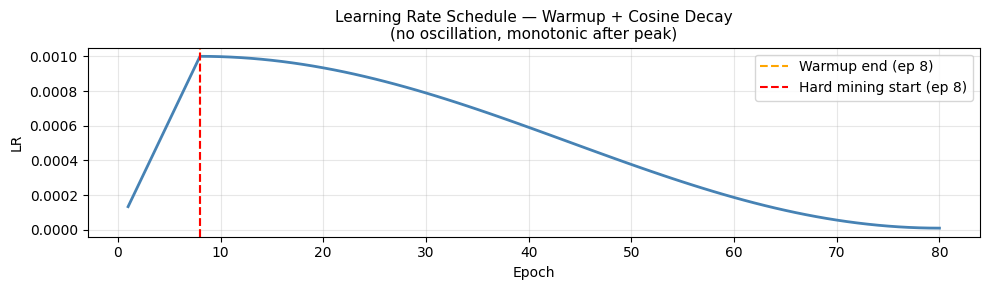

Optimizer / Scheduler / EarlyStopper ready ✓
  Peak LR    : 1.00e-03  (at ep 8)
  Min  LR    : 1.00e-05  (at ep 80)
  Warmup     : ep 1 → 8  (linear rise)
  Decay      : ep 8 → 80  (cosine, no oscillation)


In [25]:
class WarmupCosineLR(torch.optim.lr_scheduler.LambdaLR):

  def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
               min_lr_ratio: float = 0.01):
    self.warmup_epochs = warmup_epochs
    self.total_epochs = total_epochs
    self.min_lr_ratio = min_lr_ratio

    def lr_lambda(epoch):
      e = epoch + 1

      if e <= warmup_epochs:
        return (min_lr_ratio + (1.0 - min_lr_ratio) * e / warmup_epochs)

      # Corrected: Ensure the denominator is a single number, not a tuple
      progress = ((e - warmup_epochs) / max(1, total_epochs - warmup_epochs))
      cosine = 0.5 * (1.0 + _math.cos(_math.pi * progress))
      return min_lr_ratio + (1.0 - min_lr_ratio) * cosine
    super().__init__(optimizer, lr_lambda)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
    betas=(0.9, 0.999),
    fused=torch.cuda.is_available(),
)

# Removed OneCycleLR which was incorrectly implemented with custom args
# The original OneCycleLR expects `max_lr` and `steps_per_epoch`.
# The custom WarmupCosineLR is already defined, so it should be used instead.
# Let's instantiate the custom WarmupCosineLR.

scheduler = WarmupCosineLR(
    optimizer,
    warmup_epochs=CFG.warmup_epochs,
    total_epochs=CFG.num_epochs,
    min_lr_ratio=0.01 # Assuming min_lr_ratio is a fixed value like 0.01 based on common practice or CFG.min_lr / CFG.lr
)

scaler = GradScaler(enabled=USE_AMP)


class EarlyStopper:
    def __init__(self, patience=18, min_delta=5e-5):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float("inf")
        self.stop      = False

    def __call__(self, val_loss) -> bool:
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False


early_stopper = EarlyStopper(
    patience=CFG.patience, min_delta=CFG.min_delta)

_preview_lrs = []
_opt_tmp = torch.optim.AdamW(
    [torch.nn.Parameter(torch.zeros(1))], lr=CFG.lr)

# Use the correct class name for the temporary scheduler
_sch_tmp = WarmupCosineLR(
    _opt_tmp,
    warmup_epochs=CFG.warmup_epochs,
    total_epochs=CFG.num_epochs,
    min_lr_ratio=0.01,
)
for _ in range(CFG.num_epochs):
    _preview_lrs.append(_opt_tmp.param_groups[0]["lr"])
    _sch_tmp.step()

plt.figure(figsize=(10, 3))
plt.plot(range(1, CFG.num_epochs + 1), _preview_lrs,
         color="steelblue", lw=2)
plt.axvline(CFG.warmup_epochs, color="orange",
            ls="--", lw=1.5,
            label=f"Warmup end (ep {CFG.warmup_epochs})")
plt.axvline(CFG.mining_start, color="red",
            ls="--", lw=1.5,
            label=f"Hard mining start (ep {CFG.mining_start})")
plt.title("Learning Rate Schedule — Warmup + Cosine Decay\n"
          "(no oscillation, monotonic after peak)",
          fontsize=11)
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.results_dir, "lr_schedule.png"),
            dpi=120, bbox_inches="tight")
plt.show()
del _opt_tmp, _sch_tmp, _preview_lrs

print("Optimizer / Scheduler / EarlyStopper ready ✓")
print(f"  Peak LR    : {CFG.lr:.2e}  (at ep {CFG.warmup_epochs})")
print(f"  Min  LR    : {CFG.min_lr:.2e}  (at ep {CFG.num_epochs})")
print(f"  Warmup     : ep 1 → {CFG.warmup_epochs}  (linear rise)")
print(f"  Decay      : ep {CFG.warmup_epochs} → {CFG.num_epochs}  (cosine, no oscillation)")

In [26]:
# ================================================================
# CELL 13A: Initial LLE + UMAP Fit
# Fits both reducers on CNN embeddings before training starts.
# ================================================================

def umap_transform_batch(
    cnn_emb_tensor, lle_red, umap_red, device
):
    """CNN tensor → LLE → UMAP → GPU tensor."""
    arr = cnn_emb_tensor.cpu().float().detach().numpy()
    lle_out = lle_red.transform(arr)
    umap_out = umap_red.transform(lle_out)
    return torch.tensor(umap_out, dtype=torch.float32).to(device)


print("=" * 60)
print("  INITIAL LLE + UMAP FIT")
print("=" * 60)

print("\n[1/3] Extracting CNN embeddings from training set ...")

init_cnn_embs, init_labs = extract_cnn_embeddings(
    train_face_ds, model, DEVICE, max_imgs=min(len(train_face_ds), 1000)
)

# Prevent singular matrix
init_cnn_embs = init_cnn_embs + 1e-6 * np.random.randn(*init_cnn_embs.shape)

print(f"  CNN embeddings : {init_cnn_embs.shape}")
print(f"  Identities     : {len(np.unique(init_labs))}")

print("\n[2/3] Fitting Supervised LLE ...")
lle_reducer.fit(init_cnn_embs, init_labs)

print("\n[3/3] Fitting Supervised UMAP on LLE output ...")
init_lle_embs = lle_reducer.transform(init_cnn_embs)
umap_reducer.fit(init_lle_embs, init_labs)# Sanity check full pipeline
_test_umap = umap_transform_batch(torch.tensor(init_cnn_embs[:4]), lle_reducer, umap_reducer, DEVICE)

print("\nPipeline sanity check:")
print(f"  CNN in  : {init_cnn_embs[:4].shape}")
print(f"  UMAP out: {tuple(_test_umap.shape)}")
del _test_umap

# History + state
history = {
    "train_loss": [],
    "val_loss": [],
    "trip_loss": [],
    "ce_loss": [],
    "EER": [],
    "AUC": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "lr": [],
}
best_val_loss = float("inf")
best_ckpt_path = os.path.join(CFG.ckpt_dir, "best_model.pth")
metrics = {}
_mining_done = False
W = len(str(CFG.num_epochs))

print("\n" + "=" * 60)
print("  Cell 13A complete — ready for training")
print("=" * 60)


  INITIAL LLE + UMAP FIT

[1/3] Extracting CNN embeddings from training set ...
  CNN embeddings : (1000, 512)
  Identities     : 31

[2/3] Fitting Supervised LLE ...
  Supervised LLE fitting on 1000 × 512 ...
  Supervised LLE done in 1.5s  → shape (1000, 128)

[3/3] Fitting Supervised UMAP on LLE output ...
  UMAP fitting on 1000 × 128 (supervised=True) ...
  UMAP done in 10.0s  → shape (1000, 64)

Pipeline sanity check:
  CNN in  : (4, 512)
  UMAP out: (4, 64)

  Cell 13A complete — ready for training


In [27]:
# ================================================================
# CELL 13B: Train / Validate / run_epoch Functions
# ================================================================

def train_one_epoch(mdl, loader, opt, sch,
                     loss_fn, lle_red, umap_red,
                     device, scl):
    mdl.train()
    tot_loss = tot_trip = tot_ce = 0.0
    n_b = 0

    for a, p, n, la in loader:
        a  = a.to(device, non_blocking=True)
        p  = p.to(device, non_blocking=True)
        n  = n.to(device, non_blocking=True)
        la = la.to(device, non_blocking=True)
        lp = la
        ln = torch.zeros_like(la)

        opt.zero_grad(set_to_none=True)

        with autocast(enabled=USE_AMP):
            # Single fused CNN pass for all 3 streams
            imgs_cat = torch.cat([a, p, n], dim=0)
            cnn_emb  = mdl.get_cnn_embedding(imgs_cat)

            # LLE → UMAP (CPU numpy → GPU tensor)
            umap_emb = umap_transform_batch(
                cnn_emb, lle_red, umap_red, device)

            # Siamese + ArcFace
            labels_cat       = torch.cat([la, lp, ln], dim=0)
            sia_emb, logits  = mdl(umap_emb, labels_cat)
            ea, ep, en       = torch.chunk(sia_emb, 3, dim=0)
            lo_a, lo_p, lo_n = torch.chunk(logits,  3, dim=0)

            loss, t_l, c_l = loss_fn(
                ea, ep, en,
                lo_a, lo_p, lo_n,
                la, lp, ln)

        scl.scale(loss).backward()
        scl.unscale_(opt)
        nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
        scl.step(opt)
        scl.update()

        tot_loss += loss.item()
        tot_trip += t_l
        tot_ce   += c_l
        n_b      += 1

    nb = max(n_b, 1)
    return tot_loss/nb, tot_trip/nb, tot_ce/nb


@torch.inference_mode()
def validate(mdl, loader, loss_fn,
              lle_red, umap_red, device):
    mdl.eval()
    total_loss = 0.0
    n_b = 0

    for a, p, n, la in loader:
        a  = a.to(device, non_blocking=True)
        p  = p.to(device, non_blocking=True)
        n  = n.to(device, non_blocking=True)
        la = la.to(device, non_blocking=True)
        lp = la
        ln = torch.zeros_like(la)

        with autocast(enabled=USE_AMP):
            imgs_cat         = torch.cat([a, p, n], dim=0)
            cnn_emb          = mdl.get_cnn_embedding(imgs_cat)
            umap_emb         = umap_transform_batch(
                                   cnn_emb, lle_red,
                                   umap_red, device)
            labels_cat       = torch.cat([la, lp, ln], dim=0)
            sia_emb, logits  = mdl(umap_emb, labels_cat)
            ea, ep, en       = torch.chunk(sia_emb, 3, dim=0)
            lo_a, lo_p, lo_n = torch.chunk(logits,  3, dim=0)
            loss, _, _ = loss_fn(
                ea, ep, en,
                lo_a, lo_p, lo_n,
                la, lp, ln)

        total_loss += loss.item()
        n_b        += 1

    return total_loss / max(n_b, 1)


def run_epoch(epoch):
    global best_val_loss, metrics, _mining_done
    global train_loader, scheduler

    t0 = time.time()

    # ── LLE + UMAP refit ──────────────────────────────────────
    lle_due  = (epoch > 1 and
                epoch % CFG.lle_refit_every == 0)
    umap_due = (epoch > 1 and
                epoch % CFG.umap_refit_every == 0)

    if lle_due or umap_due:
        print(f"\n[Ep {epoch:{W}}] Refitting reducers ...")
        cnn_tr, labs_tr = extract_cnn_embeddings(
            train_face_ds, model, DEVICE,
            max_imgs=min(len(train_face_ds), 1000),
            split= "train")

        if lle_due:
            lle_reducer.fit(cnn_tr, labs_tr)
        lle_tr = lle_reducer.transform(cnn_tr)

        if umap_due:
            umap_reducer.fit(lle_tr, labs_tr)

    # ── Hard mining ───────────────────────────────────────────
    if epoch == CFG.mining_start and not _mining_done:
        print(f"\n[Ep {epoch:{W}}] Hard negative mining ...")
        cnn_tr, labs_tr = extract_cnn_embeddings(
            train_face_ds, model, DEVICE,
            split="train")
        train_triplet.refresh_hard(cnn_tr, labs_tr)
        train_loader = make_loader(
            train_triplet, CFG.batch_size,
            shuffle=True, drop_last=True)
        _mining_done = True
        print(f"  Hard mining done — "
              f"LR continues cosine decay uninterrupted "
              f"({optimizer.param_groups[0]['lr']:.2e})")

    # ── Train ─────────────────────────────────────────────────
    tr_loss, tr_trip, tr_ce = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, lle_reducer, umap_reducer, DEVICE, scaler)
    scheduler.step()
    invalidate_cnn_cache()

    # ── Validate ──────────────────────────────────────────────
    va_loss = validate(
        model, val_loader, criterion,
        lle_reducer, umap_reducer, DEVICE)

    cur_lr = optimizer.param_groups[0]["lr"]

 # ── Biometric eval ────────────────────────────────────────
    do_eval = (epoch % CFG.eval_every == 0
               or epoch == 1
               or epoch == CFG.num_epochs)

    if do_eval:
        # Extract fresh CNN embeddings then run full pipeline
        cnn_e, labs_e = extract_cnn_embeddings(
            val_face_ds, model, DEVICE,
            max_imgs=CFG.max_eval_imgs,
            split="val")
        sia_e = extract_full_embeddings(
            cnn_e, labs_e,
            lle_reducer, umap_reducer,
            model, DEVICE)
        m = compute_verification_metrics(
            sia_e, labs_e, CFG.n_thresholds)
        if m:
            metrics = m
            eer   = m["EER"]
            auc_v = m["AUC"]
            acc   = m["accuracy"]
            prec  = m["precision"]
            rec   = m["recall"]
        else:
            eer = auc_v = acc = prec = rec = float("nan")
    else:
        eer = auc_v = acc = prec = rec = float("nan")

    # ── History ───────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["trip_loss"].append(tr_trip)
    history["ce_loss"].append(tr_ce)
    history["EER"].append(eer)
    history["AUC"].append(auc_v)
    history["accuracy"].append(acc)
    history["precision"].append(prec)
    history["recall"].append(rec)
    history["lr"].append(cur_lr)

    # ── Checkpoint ────────────────────────────────────────────
    is_best = early_stopper(va_loss)
    if is_best:
        best_val_loss = va_loss
        torch.save({
            "epoch":           epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_loss":        va_loss,
            "EER":             eer,
            "AUC":             auc_v,
            "cfg": {
                "cnn_emb_dim": CFG.cnn_emb_dim,
                "lle_out":     CFG.lle_output_dim,
                "umap_out":    CFG.umap_output_dim,
                "sia_emb_dim": CFG.sia_emb_dim,
                "img_size":    CFG.img_size,
                "n_ids":       N_IDS,
            },
        }, best_ckpt_path)
        saved = "  ✓"
    else:
        saved = ""

    # ── Print ─────────────────────────────────────────────────
    fmt  = lambda v: f"{v:.3f}" if not math.isnan(v) else "  — "
    ep_t = time.time() - t0

    print(f"Ep {epoch:{W}}/{CFG.num_epochs} | "
          f"Tr {tr_loss:.4f} "
          f"(T {tr_trip:.3f} C {tr_ce:.3f}) | "
          f"Va {va_loss:.4f} | "
          f"EER {fmt(eer)} | "
          f"AUC {fmt(auc_v)} | "
          f"Acc {fmt(acc)} | "
          f"P {fmt(prec)} R {fmt(rec)} | "
          f"LR {cur_lr:.2e} | "
          f"{ep_t:.1f}s{saved}")

    if early_stopper.stop:
        print(f"\n  Early stopping at epoch {epoch}.")
        return False
    return True


print("=" * 60)
print("  Cell 13B complete — all functions defined")
print("=" * 60)

  Cell 13B complete — all functions defined


In [28]:
def umap_transform_batch(cnn_emb_tensor, lle_red, umap_red, device):
    """CNN tensor → LLE → UMAP → GPU tensor (safe version)."""

    # Detach tensor from computation graph before numpy conversion
    arr = cnn_emb_tensor.detach().cpu().float().numpy()

    # LLE reduction
    lle_out = lle_red.transform(arr)

    # UMAP reduction
    umap_out = umap_red.transform(lle_out)

    # Convert back to torch tensor
    out = torch.from_numpy(umap_out).float().to(device)

    return out

In [29]:
# ================================================================
# CELL 13C: Training Loop Execution
# Re-run this cell alone to resume after interruption.
# ================================================================

print("=" * 72)
print("  TRAINING  (MobileNet → LLE → UMAP → Siamese → ArcFace)")
print(f"  Epochs        : {CFG.num_epochs:<6}  "
      f"Eval every  : {CFG.eval_every}")
print(f"  Hard mining   : ep {CFG.mining_start:<5}  "
      f"LLE refit   : every {CFG.lle_refit_every} ep")
print(f"  LLE           : {CFG.cnn_emb_dim}D → {CFG.lle_output_dim}D  "
      f"UMAP            : {CFG.lle_output_dim}D → {CFG.umap_output_dim}D")
print(f"  AMP           : {USE_AMP:<6}  "
      f"torch.compile: {_compiled}")
print("=" * 72)

start_epoch = len(history["train_loss"]) + 1

if start_epoch > CFG.num_epochs:
    print(f"  Already complete ({CFG.num_epochs} epochs done).")
else:
    if start_epoch > 1:
        print(f"  Resuming from epoch {start_epoch} ...")

    t_start = time.time()

    for epoch in range(start_epoch, CFG.num_epochs + 1):
        if not run_epoch(epoch):
            break

    total_min = (time.time() - t_start) / 60
    done_eps  = len(history["train_loss"])

    valid_eers = [v for v in history["EER"]
                  if not math.isnan(v)]
    valid_aucs = [v for v in history["AUC"]
                  if not math.isnan(v)]

    print("\n" + "=" * 72)
    print("  TRAINING COMPLETE")
    print("=" * 72)
    print(f"  Epochs trained   : {done_eps}")
    print(f"  Total time       : {total_min:.1f} min  "
          f"({total_min/max(done_eps,1)*60:.1f} s/epoch avg)")
    print(f"  Best val loss    : {best_val_loss:.4f}")
    if valid_eers:
        be = min(valid_eers)
        print(f"  Best EER         : {be*100:.2f}%  "
              f"(ep {history['EER'].index(be)+1})")
    if valid_aucs:
        ba = max(valid_aucs)
        print(f"  Best AUC         : {ba:.4f}  "
              f"(ep {history['AUC'].index(ba)+1})")
    print(f"  Checkpoint       : {best_ckpt_path}")
    print("=" * 72)
    print("Proceed to Cell 14 → Evaluation Dashboard")

  TRAINING  (MobileNet → LLE → UMAP → Siamese → ArcFace)
  Epochs        : 80      Eval every  : 5
  Hard mining   : ep 8      LLE refit   : every 15 ep
  LLE           : 512D → 128D  UMAP            : 128D → 64D
  AMP           : 1       torch.compile: False
Ep  1/80 | Tr 16.4883 (T 0.868 C 39.919) | Va 13.5857 | EER 0.503 | AUC 0.501 | Acc 0.550 | P 0.033 R 0.441 | LR 2.58e-04 | 353.7s  ✓
Ep  2/80 | Tr 13.5434 (T 0.893 C 32.519) | Va 12.8252 | EER   —  | AUC   —  | Acc   —  | P   —  R   —  | LR 3.81e-04 | 339.9s  ✓
Ep  3/80 | Tr 12.7015 (T 0.901 C 30.403) | Va 12.5430 | EER   —  | AUC   —  | Acc   —  | P   —  R   —  | LR 5.05e-04 | 338.8s  ✓
Ep  4/80 | Tr 11.7038 (T 0.875 C 27.946) | Va 10.3997 | EER   —  | AUC   —  | Acc   —  | P   —  R   —  | LR 6.29e-04 | 336.8s  ✓
Ep  5/80 | Tr 8.0042 (T 0.854 C 18.729) | Va 5.3592 | EER 0.503 | AUC 0.493 | Acc 0.499 | P 0.033 R 0.495 | LR 7.52e-04 | 339.5s  ✓
Ep  6/80 | Tr 2.6224 (T 0.854 C 5.274) | Va 0.7916 | EER   —  | AUC   —  | Acc   —  | P

In [30]:
# ================================================================
# CELL 14: K-Fold Cross-Validation
# Runs CFG.n_folds-fold stratified CV for reliable performance.
# ================================================================

print(f"Running {CFG.n_folds}-Fold Cross-Validation ...")
print("(Uses best checkpoint model with no retraining)\n")

all_samples, all_labels, _ = collect_samples(
    CFG.data_dir, CFG.min_imgs_cls)

skf      = StratifiedKFold(
    n_splits=CFG.n_folds,
    shuffle=True,
    random_state=SEED)

fold_metrics = []

# Load best model
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

for fold, (tr_idx, va_idx) in enumerate(
        skf.split(all_samples, all_labels), 1):

    print(f"  Fold {fold}/{CFG.n_folds} ...")

    fold_samples = [all_samples[i] for i in va_idx]
    fold_labels  = [all_labels[i]  for i in va_idx]

    fold_ds = FaceDataset(
        list(zip(fold_samples, fold_labels)),
        get_val_transform(CFG), detector)

    cnn_e, labs_e = extract_cnn_embeddings(
        fold_ds, model, DEVICE)
    sia_e = extract_full_embeddings(
        cnn_e, labs_e,
        lle_reducer, umap_reducer,
        model, DEVICE)
    m = compute_verification_metrics(
        sia_e, labs_e, CFG.n_thresholds)

    if m:
        fold_metrics.append({
            "fold":      fold,
            "EER_%":     round(m["EER"] * 100, 3),
            "AUC":       round(m["AUC"], 4),
            "accuracy":  round(m["accuracy"] * 100, 3),
            "precision": round(m["precision"], 4),
            "recall":    round(m["recall"], 4),
            "n_genuine": m["n_genuine"],
            "n_impostor":m["n_impostor"],
        })
        print(f"    EER {m['EER']*100:.2f}%  "
              f"AUC {m['AUC']:.4f}  "
              f"Acc {m['accuracy']*100:.2f}%  "
              f"P {m['precision']:.3f}  "
              f"R {m['recall']:.3f}")

# Summary
if fold_metrics:
    eers  = [f["EER_%"]     for f in fold_metrics]
    aucs  = [f["AUC"]       for f in fold_metrics]
    accs  = [f["accuracy"]  for f in fold_metrics]
    precs = [f["precision"] for f in fold_metrics]
    recs  = [f["recall"]    for f in fold_metrics]

    print("\n" + "=" * 56)
    print(f"  {CFG.n_folds}-FOLD CV SUMMARY")
    print("=" * 56)
    print(f"  EER      : {np.mean(eers):.2f}% "
          f"± {np.std(eers):.2f}%")
    print(f"  AUC      : {np.mean(aucs):.4f} "
          f"± {np.std(aucs):.4f}")
    print(f"  Accuracy : {np.mean(accs):.2f}% "
          f"± {np.std(accs):.2f}%")
    print(f"  Precision: {np.mean(precs):.4f} "
          f"± {np.std(precs):.4f}")
    print(f"  Recall   : {np.mean(recs):.4f} "
          f"± {np.std(recs):.4f}")
    print("=" * 56)

Running 5-Fold Cross-Validation ...
(Uses best checkpoint model with no retraining)

  Fold 1/5 ...
    EER 48.21%  AUC 0.5262  Acc 53.43%  P 0.035  R 0.500
  Fold 2/5 ...
    EER 48.16%  AUC 0.5263  Acc 50.74%  P 0.035  R 0.530
  Fold 3/5 ...
    EER 49.05%  AUC 0.5186  Acc 51.21%  P 0.034  R 0.507
  Fold 4/5 ...
    EER 48.00%  AUC 0.5266  Acc 52.55%  P 0.036  R 0.514
  Fold 5/5 ...
    EER 49.53%  AUC 0.5135  Acc 50.85%  P 0.033  R 0.501

  5-FOLD CV SUMMARY
  EER      : 48.59% ± 0.60%
  AUC      : 0.5222 ± 0.0053
  Accuracy : 51.76% ± 1.06%
  Precision: 0.0348 ± 0.0008
  Recall   : 0.5103 ± 0.0111



  FINAL EVALUATION
  Genuine pairs    :    4,333
  Impostor pairs   :  126,995
  Accuracy @ EER   :   50.53%
  Precision        :   0.0345
  Recall           :   0.5190
  AUC-ROC          :   0.5197
  EER              :   48.81%
  EER Threshold    :  0.00060


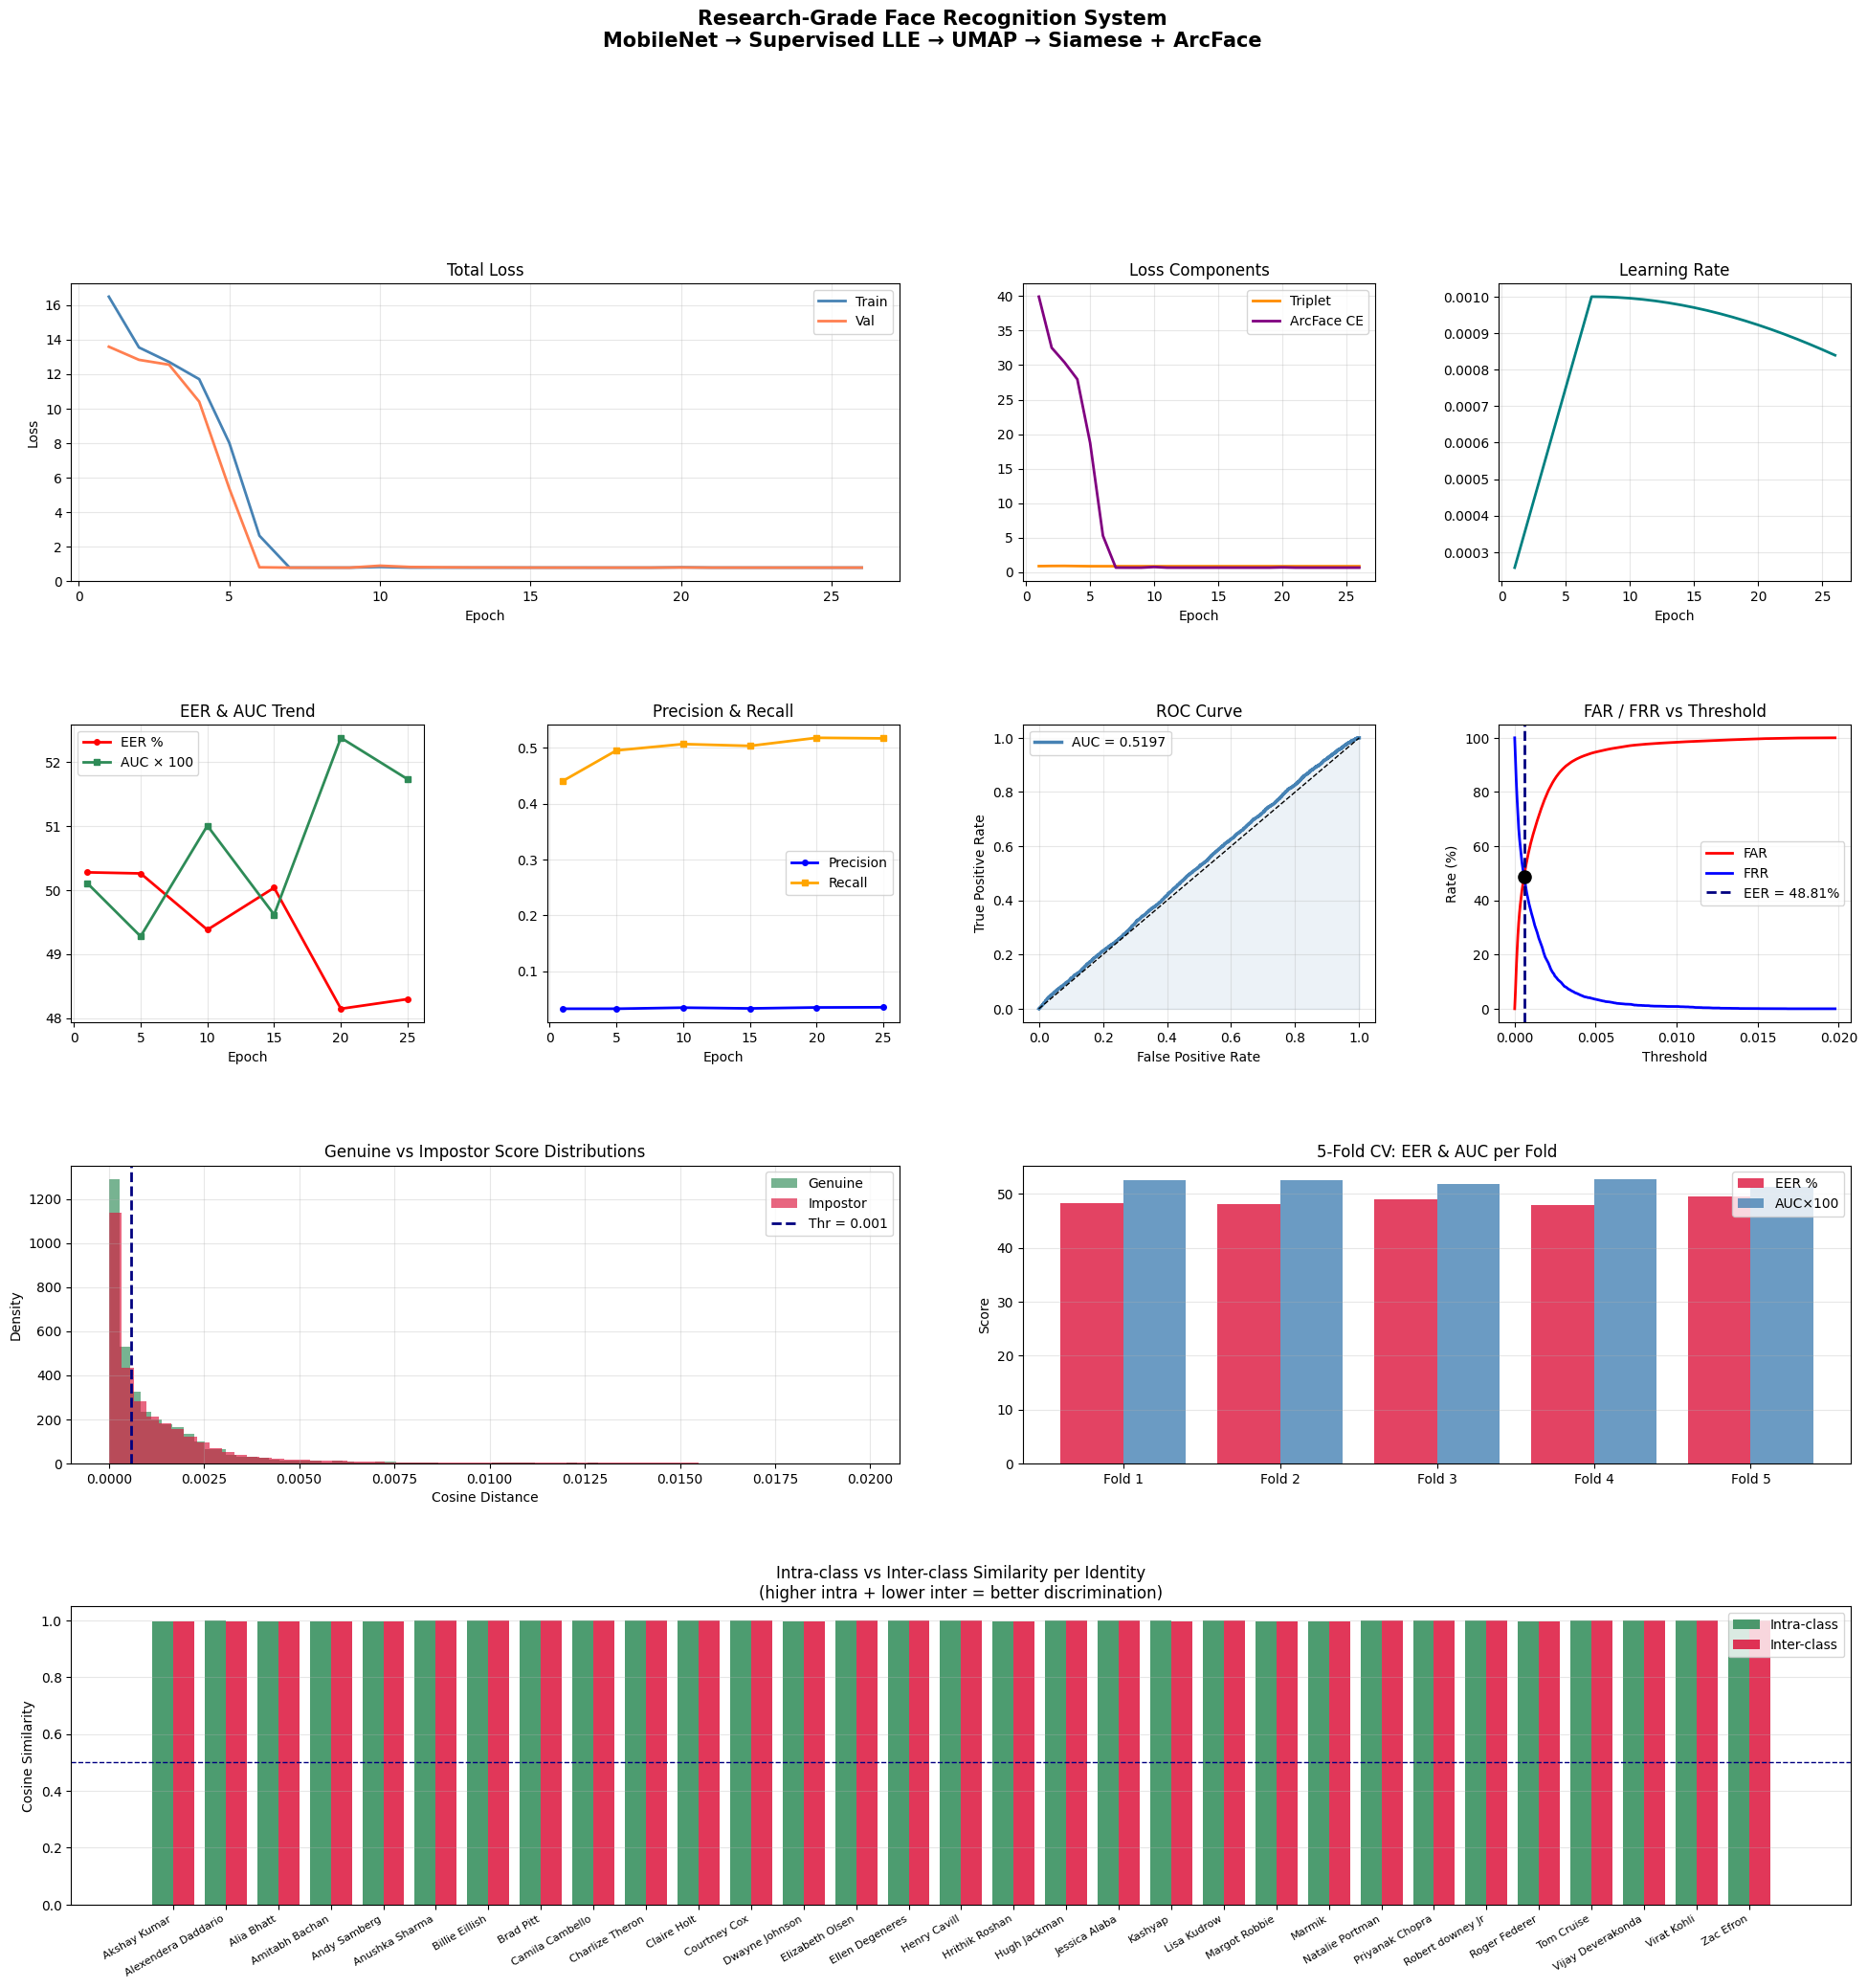

Dashboard saved ✓


In [31]:
# ================================================================
# CELL 15: Final Evaluation + Dashboard
# ================================================================

ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

cnn_e_val, labs_val = extract_cnn_embeddings(
    val_face_ds, model, DEVICE)
sia_e_val = extract_full_embeddings(
    cnn_e_val, labs_val,
    lle_reducer, umap_reducer, model, DEVICE)
metrics = compute_verification_metrics(
    sia_e_val, labs_val, CFG.n_thresholds)

print("\n" + "=" * 56)
print("  FINAL EVALUATION")
print("=" * 56)
print(f"  Genuine pairs    : {metrics['n_genuine']:>8,}")
print(f"  Impostor pairs   : {metrics['n_impostor']:>8,}")
print(f"  Accuracy @ EER   : {metrics['accuracy']*100:>7.2f}%")
print(f"  Precision        : {metrics['precision']:>8.4f}")
print(f"  Recall           : {metrics['recall']:>8.4f}")
print(f"  AUC-ROC          : {metrics['AUC']:>8.4f}")
print(f"  EER              : {metrics['EER']*100:>7.2f}%")
print(f"  EER Threshold    : {metrics['EER_threshold']:>8.5f}")
print("=" * 56)

# ── Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 22))
gs  = plt.GridSpec(4, 4, figure=fig,
                    hspace=0.48, wspace=0.35)

ep = range(1, len(history["train_loss"]) + 1)

# 1. Loss curves
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(ep, history["train_loss"],
         label="Train", color="steelblue", lw=2)
ax1.plot(ep, history["val_loss"],
         label="Val",   color="coral",     lw=2)
ax1.set_title("Total Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# 2. Component losses
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(ep, history["trip_loss"],
         label="Triplet",    color="darkorange", lw=2)
ax2.plot(ep, history["ce_loss"],
         label="ArcFace CE", color="purple",     lw=2)
ax2.set_title("Loss Components")
ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

# 3. LR schedule
ax3 = fig.add_subplot(gs[0, 3])
ax3.plot(ep, history["lr"], color="teal", lw=2)
ax3.set_title("Learning Rate")
ax3.set_xlabel("Epoch"); ax3.grid(alpha=0.3)

# 4. EER / AUC trend
ax4 = fig.add_subplot(gs[1, 0])
ep_c  = [i+1 for i, v in enumerate(history["EER"])
          if not math.isnan(v)]
eer_c = [v for v in history["EER"]  if not math.isnan(v)]
auc_c = [v for v in history["AUC"]  if not math.isnan(v)]
ax4.plot(ep_c, [v*100 for v in eer_c],
         color="red",      lw=2, marker="o", ms=4,
         label="EER %")
ax4.plot(ep_c, [v*100 for v in auc_c],
         color="seagreen", lw=2, marker="s", ms=4,
         label="AUC × 100")
ax4.set_title("EER & AUC Trend")
ax4.set_xlabel("Epoch"); ax4.legend(); ax4.grid(alpha=0.3)

# 5. Precision / Recall trend
ax5 = fig.add_subplot(gs[1, 1])
pr_c  = [v for v in history["precision"] if not math.isnan(v)]
re_c  = [v for v in history["recall"]    if not math.isnan(v)]
ax5.plot(ep_c, pr_c, color="blue",   lw=2,
         marker="o", ms=4, label="Precision")
ax5.plot(ep_c, re_c, color="orange", lw=2,
         marker="s", ms=4, label="Recall")
ax5.set_title("Precision & Recall")
ax5.set_xlabel("Epoch"); ax5.legend(); ax5.grid(alpha=0.3)

# 6. ROC curve
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(metrics["fpr"], metrics["tpr"],
         color="steelblue", lw=2.5,
         label=f"AUC = {metrics['AUC']:.4f}")
ax6.plot([0, 1], [0, 1], "k--", lw=1)
ax6.fill_between(metrics["fpr"], metrics["tpr"],
                  alpha=0.1, color="steelblue")
ax6.set_title("ROC Curve")
ax6.set_xlabel("False Positive Rate")
ax6.set_ylabel("True Positive Rate")
ax6.legend(); ax6.grid(alpha=0.3)

# 7. FAR / FRR
ax7 = fig.add_subplot(gs[1, 3])
ax7.plot(metrics["thresholds"], metrics["FAR"] * 100,
         color="red",  lw=2, label="FAR")
ax7.plot(metrics["thresholds"], metrics["FRR"] * 100,
         color="blue", lw=2, label="FRR")
ax7.axvline(metrics["EER_threshold"], color="navy",
            ls="--", lw=2,
            label=f"EER = {metrics['EER']*100:.2f}%")
ax7.scatter([metrics["EER_threshold"]],
            [metrics["EER"] * 100],
            color="black", s=90, zorder=5)
ax7.set_title("FAR / FRR vs Threshold")
ax7.set_xlabel("Threshold"); ax7.set_ylabel("Rate (%)")
ax7.legend(); ax7.grid(alpha=0.3)

# 8. Score distributions
ax8 = fig.add_subplot(gs[2, :2])
ax8.hist(metrics["genuine"],  bins=60, alpha=0.65,
         color="seagreen", label="Genuine",  density=True)
ax8.hist(metrics["impostor"], bins=60, alpha=0.65,
         color="crimson",  label="Impostor", density=True)
ax8.axvline(metrics["EER_threshold"], color="navy",
            ls="--", lw=2,
            label=f"Thr = {metrics['EER_threshold']:.3f}")
ax8.set_title("Genuine vs Impostor Score Distributions")
ax8.set_xlabel("Cosine Distance")
ax8.set_ylabel("Density")
ax8.legend(); ax8.grid(alpha=0.3)

# 9. K-Fold results bar chart
ax9 = fig.add_subplot(gs[2, 2:])
if fold_metrics:
    folds  = [f["fold"]     for f in fold_metrics]
    f_eers = [f["EER_%"]    for f in fold_metrics]
    f_aucs = [f["AUC"]*100  for f in fold_metrics]
    x      = np.arange(len(folds))
    ax9.bar(x - 0.2, f_eers, 0.4,
             label="EER %",   color="crimson",  alpha=0.8)
    ax9.bar(x + 0.2, f_aucs, 0.4,
             label="AUC×100", color="steelblue", alpha=0.8)
    ax9.set_xticks(x)
    ax9.set_xticklabels([f"Fold {f}" for f in folds])
    ax9.set_title(f"{CFG.n_folds}-Fold CV: EER & AUC per Fold")
    ax9.set_ylabel("Score")
    ax9.legend(); ax9.grid(alpha=0.3, axis="y")

# 10. Intra vs Inter-class similarity per identity
ax10 = fig.add_subplot(gs[3, :])
intra, inter, id_names = [], [], []
for cid in np.unique(labs_val):
    mask = labs_val == cid
    if mask.sum() < 2:
        continue
    cls_e = sia_e_val[mask]
    oth_e = sia_e_val[~mask]
    sim_in = cls_e @ cls_e.T
    np.fill_diagonal(sim_in, np.nan)
    intra.append(float(np.nanmean(sim_in)))
    if len(oth_e):
        inter.append(float((cls_e @ oth_e.T).mean()))
    else:
        inter.append(0.0)
    name = [k for k, v in LABEL_ENC.items() if v == cid]
    id_names.append(name[0] if name else str(cid))

x = np.arange(len(intra))
ax10.bar(x - 0.2, intra, 0.4,
          label="Intra-class", color="seagreen", alpha=0.85)
ax10.bar(x + 0.2, inter, 0.4,
          label="Inter-class", color="crimson",  alpha=0.85)
ax10.set_xticks(x)
ax10.set_xticklabels(
    id_names, rotation=30, ha="right", fontsize=8)
ax10.set_ylabel("Cosine Similarity")
ax10.set_title(
    "Intra-class vs Inter-class Similarity per Identity\n"
    "(higher intra + lower inter = better discrimination)")
ax10.legend(); ax10.grid(alpha=0.3, axis="y")
ax10.axhline(0.5, color="navy", ls="--", lw=1)

plt.suptitle(
    "Research-Grade Face Recognition System\n"
    "MobileNet → Supervised LLE → UMAP → Siamese + ArcFace",
    fontsize=15, fontweight="bold", y=1.01)
plt.savefig(
    os.path.join(CFG.results_dir, "dashboard.png"),
    dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved ✓")

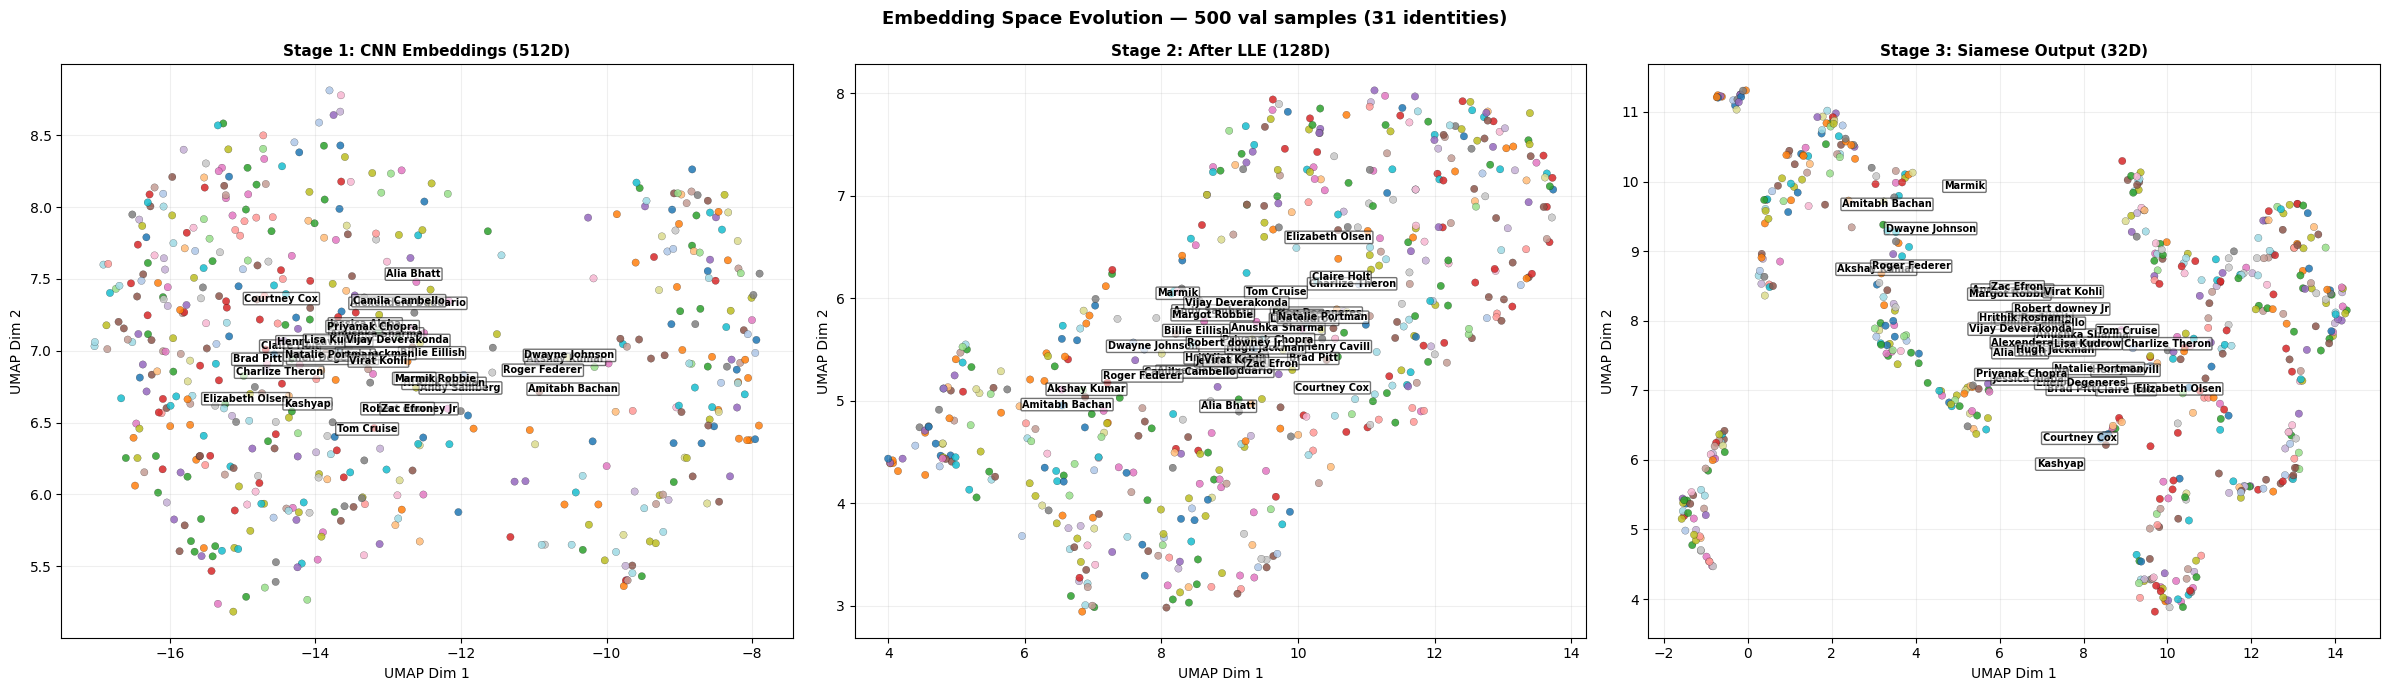

Manifold visualisation saved ✓


In [32]:
# ================================================================
# CELL 16: 3-Stage UMAP Visualisation
# CNN raw embeddings  →  LLE output  →  Final Siamese embeddings
# ================================================================

n_plot = min(len(cnn_e_val), 500)
idx_p  = np.random.choice(
    len(cnn_e_val), n_plot, replace=False)

# Stage 1 — CNN embeddings (2D UMAP for viz)
lle_2d = lle_reducer.transform(cnn_e_val[idx_p])

umap_viz = umap.UMAP(
    n_components=2, n_neighbors=15,
    min_dist=0.1, metric="cosine",
    random_state=SEED, verbose=False)

E2_cnn  = umap_viz.fit_transform(
    StandardScaler().fit_transform(cnn_e_val[idx_p]))

# Stage 2 — LLE output (2D UMAP for viz)
E2_lle  = umap_viz.fit_transform(
    StandardScaler().fit_transform(lle_2d))

# Stage 3 — Final Siamese embeddings (2D UMAP for viz)
E2_sia  = umap_viz.fit_transform(
    StandardScaler().fit_transform(sia_e_val[idx_p]))

labs_p  = labs_val[idx_p]
id_map  = {v: k for k, v in LABEL_ENC.items()}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
stages    = [
    (E2_cnn, f"Stage 1: CNN Embeddings ({CFG.cnn_emb_dim}D)"),
    (E2_lle, f"Stage 2: After LLE ({CFG.lle_output_dim}D)"),
    (E2_sia, f"Stage 3: Siamese Output ({CFG.sia_emb_dim}D)"),
]

for ax, (E2, title) in zip(axes, stages):
    sc = ax.scatter(
        E2[:, 0], E2[:, 1], c=labs_p,
        cmap="tab20", s=28, alpha=0.85,
        edgecolors="k", linewidths=0.15)
    for cid in np.unique(labs_p):
        pts = E2[labs_p == cid]
        cx, cy = pts.mean(0)
        ax.annotate(
            id_map.get(cid, str(cid)),
            (cx, cy), fontsize=7, fontweight="bold",
            ha="center",
            bbox=dict(boxstyle="round,pad=0.12",
                      fc="white", alpha=0.55))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("UMAP Dim 1")
    ax.set_ylabel("UMAP Dim 2")
    ax.grid(alpha=0.2)

plt.suptitle(
    f"Embedding Space Evolution — {n_plot} val samples "
    f"({N_IDS} identities)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(
    os.path.join(CFG.results_dir, "manifold_viz.png"),
    dpi=150, bbox_inches="tight")
plt.show()
print("Manifold visualisation saved ✓")

Building identity gallery from training set ...
Gallery    : 31 identities
Verify thr : similarity ≥ 0.9994

Upload face images to verify:


Saving Virat Kohli_29.jpg to Virat Kohli_29.jpg


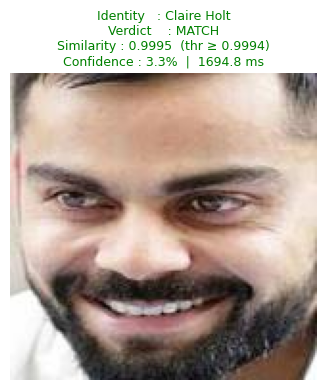


[Virat Kohli_29.jpg]
  identity          : Claire Holt
  verified          : True
  similarity        : 0.9995
  confidence_%      : 3.26
  threshold         : 0.9994
  time_ms           : 1694.77


In [33]:
# ================================================================
# CELL 17: Inference — Identity Verification
# ================================================================

print("Building identity gallery from training set ...")
cnn_g, labs_g = extract_cnn_embeddings(
    train_face_ds, model, DEVICE)
sia_g = extract_full_embeddings(
    cnn_g, labs_g, lle_reducer, umap_reducer, model, DEVICE)

gallery = {}
for cid in np.unique(labs_g):
    mask = labs_g == cid
    g    = sia_g[mask].mean(axis=0)
    gallery[cid] = g / (np.linalg.norm(g) + 1e-9)

EER_THR    = metrics.get("EER_threshold", 0.5)
VER_THR    = 1.0 - EER_THR
id_to_name = {v: k for k, v in LABEL_ENC.items()}
val_tf     = get_val_transform(CFG)

print(f"Gallery    : {len(gallery)} identities")
print(f"Verify thr : similarity ≥ {VER_THR:.4f}")


def verify_image(img_path):
    t0 = time.time()
    model.eval()

    # Preprocess
    img = Image.open(img_path).convert("RGB")
    img = detector(img)
    img = val_tf(img).unsqueeze(0).to(DEVICE)

    # CNN embedding
    with torch.no_grad():
        with autocast(enabled=USE_AMP):
            cnn_emb = model.get_cnn_embedding(img)
    cnn_np = cnn_emb.cpu().float().numpy()

    # LLE → UMAP
    lle_emb  = lle_reducer.transform(cnn_np)
    umap_emb = umap_reducer.transform(lle_emb)

    # Siamese head
    umap_t = torch.tensor(
        umap_emb, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        with autocast(enabled=USE_AMP):
            sia_emb = model.get_siamese_embedding(umap_t)
    emb = sia_emb.cpu().float().numpy()[0]

    # Gallery match
    sims    = {cid: float(np.dot(emb, ref))
               for cid, ref in gallery.items()}
    best_id = max(sims, key=sims.get)
    best_sim = sims[best_id]
    verified = best_sim >= VER_THR

    vals = np.array(list(sims.values()))
    sm   = np.exp(vals * 10); sm /= sm.sum()
    conf = float(sm.max() * 100)

    return {
        "identity":     id_to_name.get(best_id, str(best_id)),
        "verified":     verified,
        "similarity":   round(float(best_sim), 4),
        "confidence_%": round(conf, 2),
        "threshold":    round(VER_THR, 4),
        "time_ms":      round((time.time()-t0)*1000, 2),
    }


print("\nUpload face images to verify:")
test_imgs = files.upload()

for fname, data in test_imgs.items():
    tmp = f"/content/test_{fname}"
    with open(tmp, "wb") as f:
        f.write(data)

    result = verify_image(tmp)

    img_show = Image.open(tmp).convert("RGB")
    fig, ax  = plt.subplots(figsize=(4, 4))
    ax.imshow(img_show); ax.axis("off")

    verdict = "MATCH"  if result["verified"] else "NO MATCH"
    col     = "green"  if result["verified"] else "red"
    ax.set_title(
        f"Identity   : {result['identity']}\n"
        f"Verdict    : {verdict}\n"
        f"Similarity : {result['similarity']:.4f}"
        f"  (thr ≥ {result['threshold']})\n"
        f"Confidence : {result['confidence_%']:.1f}%"
        f"  |  {result['time_ms']:.1f} ms",
        fontsize=9, color=col)
    plt.tight_layout()
    plt.show()

    print(f"\n[{fname}]")
    for k, v in result.items():
        print(f"  {k:<18}: {v}")